
[array([ 436.90840967, 1890.84123   , 1728.65152833, 2873.69259167,
        898.9513245 ,  480.44222033, 1109.4800655 , 2231.02753   ,
       2662.00599667, 2523.3697    , 3094.03236333, 3193.48190833,
       3178.10061667, 2169.20483667, 2308.20947667, 2678.83964167,
       3209.31705833, 3889.40498667, 4005.91183833, 3526.50411167,
       3289.88010167, 3415.50215333, 1383.59108167,  716.63181   ,
       2120.169125  , 1845.68698667,  573.96289917,  817.054185  ,
       1397.74913333, 2380.34862167, 2873.20491   ,    0.        ]), array([3287.61870167, 3387.36673   , 3114.35908   , 2236.054525  ,
       2383.87776333, 2566.58925833, 1467.72946   , 2014.49875333,
       2410.14100167, 1679.38944   , 2371.99015833, 2976.28495833,
       3129.16113833, 3600.55635333, 3626.50229167, 2698.14663167,
       3397.66271833, 2749.41756   , 2115.69394117, 1370.10709333,
        371.21418717,  844.44854   ,  673.775606  ,  623.75014067,
       1881.55044333, 1835.714965  , 2065.15405333, 2192.1

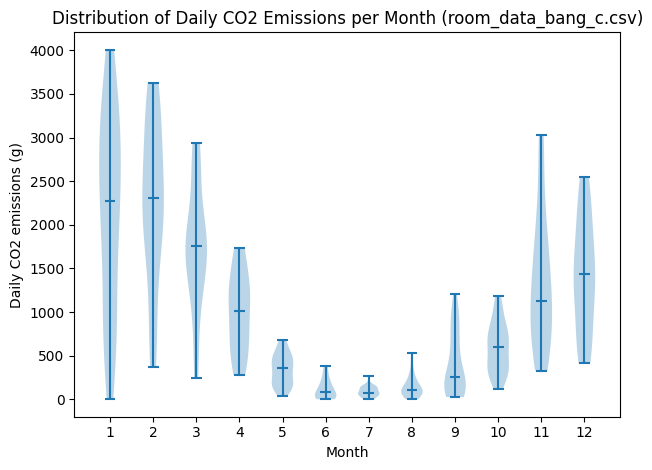

In [10]:
from scipy import stats
import itertools
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt

file_paths = glob.glob("data/room_data_bang_c.csv")

monthly_data = {}

for file in file_paths:
    df = pd.read_csv(file)

    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")




    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")

    df["dt_hours"] = df["timestamp"].diff().dt.total_seconds() / 3600
    df["energy_kwh"] = df["heating_wattage_W"] * df["dt_hours"] / 1000
    df["carbon_g"] = df["energy_kwh"] * df["carbon_intensity_gco2_per_kj"]
    print()
    df["date"] = df["timestamp"].dt.date
    daily = df.groupby("date")["carbon_g"].sum().reset_index()

    daily["date"] = pd.to_datetime(daily["date"])
    daily["month"] = daily["date"].dt.month

    data = [
        daily[daily["month"] == m]["carbon_g"].values
        for m in range(1, 13)
    ]
    print(data)

    plt.figure()
    plt.violinplot(data, positions=range(1, 13), showmedians=True)

    plt.xlabel("Month")
    plt.ylabel("Daily CO2 emissions (g)")
    plt.title("Distribution of Daily CO2 Emissions per Month (" + os.path.basename(file) + ")")

    plt.xticks(range(1, 13), range(1, 13))
    plt.tight_layout()
    plt.show()

In [11]:
from scipy import stats
import itertools
import glob
import os
import pandas as pd

file_paths = glob.glob("data/*_w*.csv")

monthly_data = {}

for file in file_paths:
    df = pd.read_csv(file)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")
    df["dt_hours"] = df["timestamp"].diff().dt.total_seconds() / 3600
    df["energy_kwh"] = df["heating_wattage_W"] * df["dt_hours"] / 1000
    df["carbon_g"] = df["energy_kwh"] * df["carbon_intensity_gco2_per_kj"]
    df["date"] = df["timestamp"].dt.date
    daily = df.groupby("date")["carbon_g"].sum().reset_index()
    daily["date"] = pd.to_datetime(daily["date"])
    daily["month"] = daily["date"].dt.month

    name = os.path.basename(file)
    monthly_data[name] = {
        m: daily[daily["month"] == m]["carbon_g"].dropna().values
        for m in range(1, 13)
    }

# ── Pairwise comparison per month ─────────────────────────────────────────────
file_names = list(monthly_data.keys())
pairs = list(itertools.combinations(file_names, 2))


for m in range(1, 13):
    print(f"  Month {m}")

    for file in file_names:
        v = monthly_data[file][m]
        _, p = stats.shapiro(v)
        if p <= 0.05:
            print(f"  {file}: {p}")
            print(p > 0.05)



  Month 1
  Month 2
  Month 3
  Month 4
  Month 5
  Month 6
  room_data_bang_w.csv: 0.014736053237469895
False
  room_data_mpc_w_0.csv: 0.017572490385168834
False
  room_data_mpc_w_6.csv: 0.004342621722044554
False
  Month 7
  Month 8
  room_data_bang_w.csv: 0.006937534177964279
False
  room_data_mpc_w_0.csv: 0.010851611331616216
False
  room_data_mpc_w_6.csv: 0.0014492568691528045
False
  Month 9
  room_data_bang_w.csv: 0.007743543927554606
False
  room_data_mpc_w_0.csv: 0.003269031634311896
False
  room_data_mpc_w_6.csv: 0.003581031386350186
False
  Month 10
  Month 11
  Month 12


In [12]:
from scipy import stats
import itertools
import glob
import os
import pandas as pd

def friedman_per_month(monthly_data: dict) -> pd.DataFrame:
    algorithms = list(monthly_data.keys())
    results = []

    for month in range(1, 13):
        groups = {algo: monthly_data[algo].get(month, []) for algo in algorithms}
        lengths = {algo: len(v) for algo, v in groups.items()}
        n = min(lengths.values())

        if n < 2:
            results.append({
                "month": month,
                "n_days": n,
                "statistic": None,
                "p_value": None,
                "significant": None,
                "note": "insufficient data",
            })
            continue

        trimmed = [groups[algo][:n] for algo in algorithms]
        any_trimmed = len(set(lengths.values())) > 1

        try:
            stat, p = stats.friedmanchisquare(*trimmed)
            results.append({
                "month": month,
                "n_days": n,
                "statistic": round(stat, 4),
                "p_value": round(p, 4),
                "significant": p < 0.05,
                "note": "trimmed to shortest" if any_trimmed else "exact",
            })
        except ValueError as e:
            results.append({
                "month": month,
                "n_days": n,
                "statistic": None,
                "p_value": None,
                "significant": None,
                "note": str(e),
            })

    return pd.DataFrame(results)


def posthoc_wilcoxon_per_month(monthly_data: dict, friedman_results: pd.DataFrame) -> pd.DataFrame:
    from statsmodels.stats.multitest import multipletests

    algorithms = list(monthly_data.keys())
    pairs = list(itertools.combinations(algorithms, 2))
    sig_months = friedman_results[friedman_results["significant"] == True]["month"].tolist()
    results = []

    for month in sig_months:
        groups = {algo: monthly_data[algo].get(month, []) for algo in algorithms}
        n = min(len(v) for v in groups.values())
        pair_results = []

        for algo_1, algo_2 in pairs:
            a, b = groups[algo_1][:n], groups[algo_2][:n]
            try:
                stat, p = stats.wilcoxon(a, b)
                pair_results.append({
                    "month": month,
                    "algo_1": algo_1,
                    "algo_2": algo_2,
                    "alg1 avg": round(sum(a)/len(a), 4),
                    "alg2 avg": round(sum(b)/len(b), 4),
                    "statistic": round(stat, 4),
                    "p_value": round(p, 4),
                })
            except ValueError as e:
                pair_results.append({
                    "month": month,
                    "algo_1": algo_1,
                    "algo_2": algo_2,
                    "statistic": None,
                    "p_value": None,
                })

        # Bonferroni correction across all pairs within this month
        pair_df = pd.DataFrame(pair_results)
        valid = pair_df["p_value"].notna()
        if valid.any():
            _, p_corr, _, _ = multipletests(pair_df.loc[valid, "p_value"], method="bonferroni")
            pair_df.loc[valid, "p_bonferroni"] = p_corr.round(4)
            pair_df.loc[valid, "significant_bonferroni"] = p_corr < 0.05

        results.append(pair_df)

    return pd.concat(results, ignore_index=True) if results else pd.DataFrame()


# --- Run ---
friedman_df = friedman_per_month(monthly_data)
print("=== Friedman Test per Month ===")
print(friedman_df.to_string(index=False))

posthoc_df = posthoc_wilcoxon_per_month(monthly_data, friedman_df)
if not posthoc_df.empty:
    print("\n=== Post-hoc Wilcoxon (significant months only) ===")
    print(posthoc_df.to_string(index=False))
else:
    print("\nNo significant months — no post-hoc tests run.")

=== Friedman Test per Month ===
 month  n_days  statistic  p_value  significant  note
     1      32    47.1024      0.0         True exact
     2      28    44.8571      0.0         True exact
     3      31    48.7742      0.0         True exact
     4      30    54.2000      0.0         True exact
     5      31    56.1935      0.0         True exact
     6      30    46.9558      0.0         True exact
     7      31    55.3571      0.0         True exact
     8      31    51.4017      0.0         True exact
     9      30    51.7815      0.0         True exact
    10      31    56.1935      0.0         True exact
    11      30    54.2000      0.0         True exact
    12      31    54.2581      0.0         True exact

=== Post-hoc Wilcoxon (significant months only) ===
 month                algo_1                algo_2  alg1 avg  alg2 avg  statistic  p_value  p_bonferroni significant_bonferroni
     1  room_data_bang_w.csv room_data_mpc_w_0.csv 2355.1918 2328.7980       68.0   0

In [15]:
MONTH_NAMES = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec',
}

def build_pivot(posthoc_df: pd.DataFrame, friedman_df: pd.DataFrame) -> pd.DataFrame:
    if posthoc_df.empty:
        print('No significant months — pivot is empty.')
        return pd.DataFrame()

    sig_months = set(
        friedman_df[friedman_df['significant'] == True]['month'].tolist()
    )

    posthoc_df = posthoc_df.copy()
    posthoc_df['pair'] = posthoc_df['algo_1'] + ' vs ' + posthoc_df['algo_2']

    def fmt_cell(row):
        if pd.isna(row.get('p_bonferroni')):
            return np.nan
        p = row['p_bonferroni']
        sig = row.get('significant_bonferroni', False)
        return f"{p:.3f}{'*' if sig else ''}"

    posthoc_df['cell'] = posthoc_df.apply(fmt_cell, axis=1)

    pivot = posthoc_df.pivot(index='pair', columns='month', values='cell')

    # Add missing months (not tested) as '—'
    for m in range(1, 13):
        if m not in pivot.columns:
            pivot[m] = np.nan
    pivot = pivot[[m for m in range(1, 13)]]

    # Replace NaN in non-significant months with '—'
    for m in range(1, 13):
        if m not in sig_months:
            pivot[m] = '—'
        else:
            pivot[m] = pivot[m].fillna('—')

    pivot.columns = [MONTH_NAMES[m] for m in pivot.columns]
    pivot.index.name = 'Pair'
    return pivot


pivot_df = build_pivot(posthoc_df, friedman_df)
pivot_df

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Pair,,,,,,,,,,,,
room_data_bang_w.csv vs room_data_mpc_w_0.csv,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*
room_data_bang_w.csv vs room_data_mpc_w_6.csv,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*
room_data_mpc_w_0.csv vs room_data_mpc_w_6.csv,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*


In [17]:
def style_pivot(pivot_df: pd.DataFrame):

    def color_cell(val):
        if isinstance(val, str) and val.endswith('*'):
            return 'background-color: #d0f0e0; color: #0a5c36; font-weight: bold;'
        if val == '—':
            return 'color: #aaa;'
        return ''

    styled = (
        pivot_df.style
        .map(color_cell)
        .set_caption(
            'Post-hoc Wilcoxon p-values (Bonferroni-corrected) | '
            '* = significant (p < 0.05) | — = month not tested'
        )
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '12px'), ('color', '#555'), ('padding-bottom', '8px')]},
            {'selector': 'th',
             'props': [('font-size', '12px'), ('font-weight', '500'),
                       ('background-color', '#f5f5f5'), ('padding', '6px 10px'),
                       ('border-bottom', '1.5px solid #ccc')]},
            {'selector': 'td',
             'props': [('font-size', '12px'), ('padding', '5px 10px'),
                       ('text-align', 'center'), ('border-bottom', '0.5px solid #e0e0e0')]},
            {'selector': 'th.row_heading',
             'props': [('text-align', 'left'), ('min-width', '160px')]},
        ])
    )
    return styled


if not pivot_df.empty:
    display(style_pivot(pivot_df))
else:
    print('Pivot is empty — no significant months found.')

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Pair,,,,,,,,,,,,
room_data_bang_w.csv vs room_data_mpc_w_0.csv,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*
room_data_bang_w.csv vs room_data_mpc_w_6.csv,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*
room_data_mpc_w_0.csv vs room_data_mpc_w_6.csv,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*,0.000*


In [25]:
def print_monthly_winners(posthoc_df: pd.DataFrame, friedman_df: pd.DataFrame):
    if posthoc_df.empty:
        print('No significant months.')
        return

    sig_months = sorted(friedman_df[friedman_df['significant'] == True]['month'].tolist())
    algorithms = sorted(set(posthoc_df['algo_1'].tolist() + posthoc_df['algo_2'].tolist()))

    print('Monthly winner (lowest average)\n' + '=' * 40)
    for month in sig_months:
        month_data = posthoc_df[posthoc_df['month'] == month]
        if month_data.empty:
            continue

        # Collect all avg values seen for this month
        avgs = {}
        for _, row in month_data.iterrows():
            if pd.notna(row.get('alg1 avg')):
                avgs[row['algo_1']] = row['alg1 avg']
            if pd.notna(row.get('alg2 avg')):
                avgs[row['algo_2']] = row['alg2 avg']

        winner = min(avgs, key=avgs.get)
        print(f"{MONTH_NAMES[month]:>4}: {winner}  (avg={avgs[winner]:.4f})")

print_monthly_winners(posthoc_df, friedman_df)


Monthly winner (lowest average)
 Jan: room_data_mpc_w_6.csv  (avg=2234.5733)
 Feb: room_data_mpc_w_6.csv  (avg=2336.4855)
 Mar: room_data_mpc_w_6.csv  (avg=1780.4618)
 Apr: room_data_mpc_w_6.csv  (avg=1007.5030)
 May: room_data_mpc_w_6.csv  (avg=342.5776)
 Jun: room_data_mpc_w_6.csv  (avg=121.3647)
 Jul: room_data_mpc_w_6.csv  (avg=97.9499)
 Aug: room_data_mpc_w_6.csv  (avg=148.9747)
 Sep: room_data_mpc_w_6.csv  (avg=427.2839)
 Oct: room_data_mpc_w_6.csv  (avg=643.7614)
 Nov: room_data_mpc_w_6.csv  (avg=1417.2121)
 Dec: room_data_mpc_w_6.csv  (avg=1500.6037)
